# Visualizing the Titanic Disaster

### Import the necessary libraries

In [2]:
import pandas as pd  
import numpy as np 

 ### See the first 5 entries

In [3]:
path = r"D:\AICourseTahlildadeh\HW1\titanic.csv"
df = pd.read_csv(path)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


###  What is the number of observations in the dataset?

In [4]:
print(len(df))

891


###  What is the number of columns in the dataset?

In [5]:
print(len(df.columns))

12


### Print the name of all the columns.

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### What is the name of 105th passenger?

In [7]:
passenger_name = df.iloc[104]['Name']
print(passenger_name)

Gustafsson, Mr. Anders Vilhelm


### Set PassengerId as the index 

In [8]:
df.set_index('PassengerId', inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Create a pie chart presenting the male/female proportion

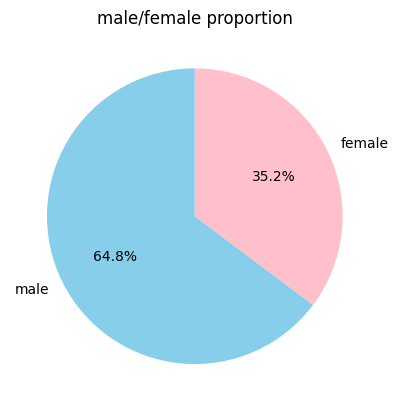

In [9]:
import matplotlib.pyplot as plt

sex_count = df['Sex'].value_counts()

sex_count.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'pink'])

plt.title("male/female proportion")
plt.show()

### Create a scatterplot with the Fare payed and the Age, differ the plot color by gender

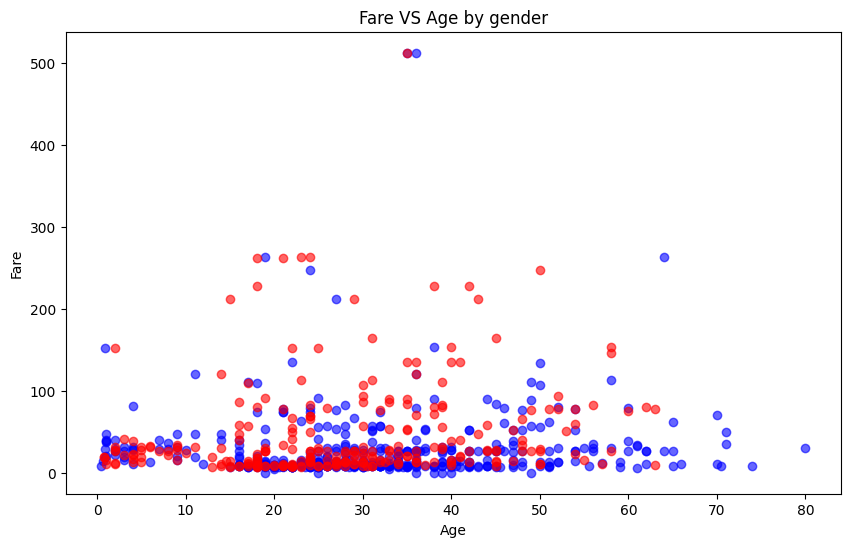

In [11]:
male = df[df['Sex'] == 'male']
female = df[df['Sex'] == 'female']

plt.figure(figsize=(10, 6))
plt.scatter(male['Age'], male['Fare'], color='blue', label='Male', alpha=0.6)
plt.scatter(female['Age'], female['Fare'], color='red', label='Female', alpha=0.6)

plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Fare VS Age by gender')
plt.show()

### How many people survived?

In [15]:
len(df[df['Survived'] == 1])

342

### Create a histogram and box plot with the Fare payed (use subplot)

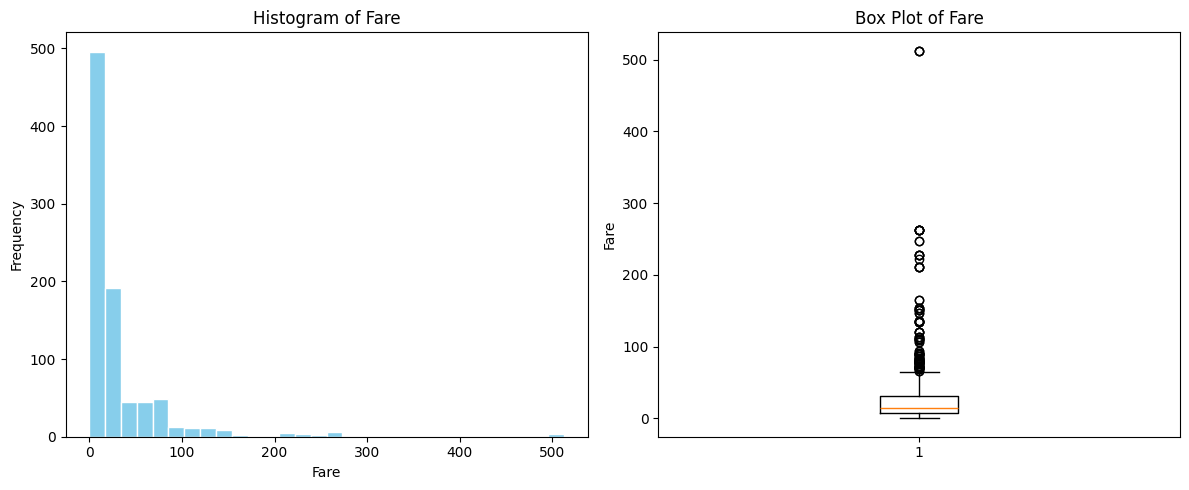

In [18]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Fare'].dropna(), bins=30, color='skyblue', edgecolor='white')
plt.title('Histogram of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(df['Fare'].dropna())
plt.title('Box Plot of Fare')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()


### Drop passengerID and Ticket columns

In [25]:
df = df.drop(columns=['Ticket'])
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S


<div dir="rtl" style="test-align: right">
در مراحل قبلی ستون PassengerId را به index تبدیل کردیم و الان دیگر ستونی به نام PassengerId نداریم که دراپ کنیم
</div>

### Is there a meaningful relationship between living and dying with age? (show relationship by visual representation)

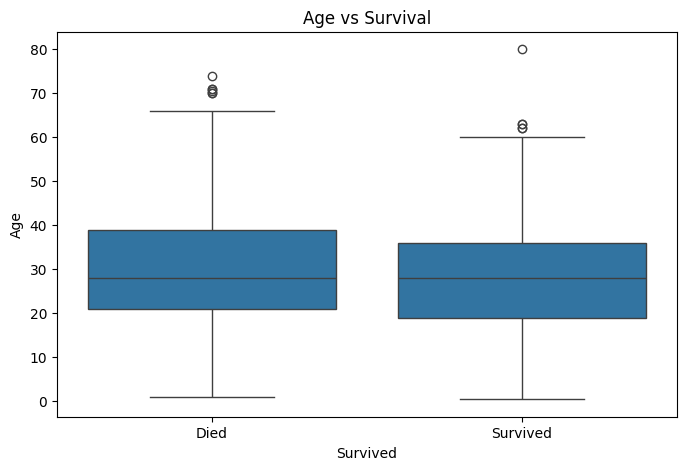

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.xticks([0, 1], ['Died', 'Survived'])
plt.title('Age vs Survival')
plt.show()


### Tell me about the relationship between the age, Pclass and sex

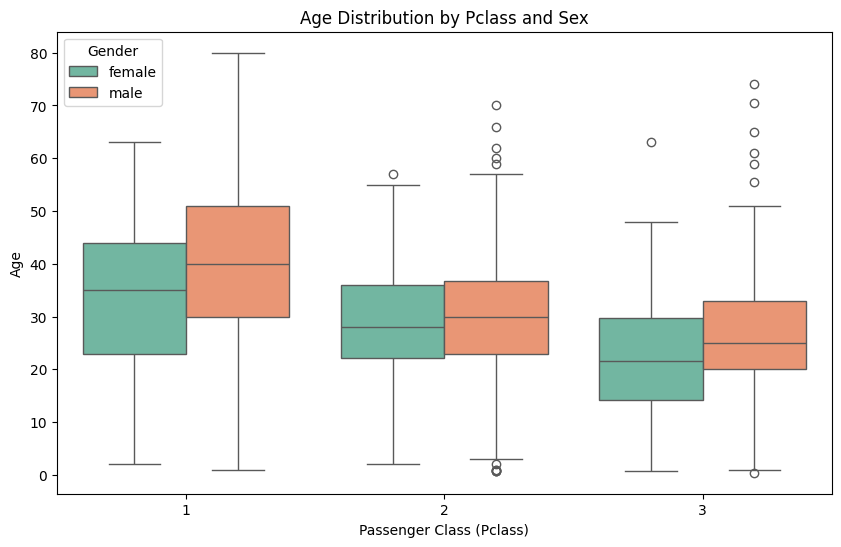

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Pclass', y='Age', hue='Sex', palette='Set2')

plt.title('Age Distribution by Pclass and Sex')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Age')
plt.legend(title='Gender')
plt.show()
